In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

In [2]:
marketing = pd.read_csv('D:\\Usuarios\\RSanabria\\OneDrive - HANSA\\Escritorio\\Marketing Analytics - Data Camp\\marketing.csv')

In [3]:
marketing.head()
print(marketing.describe())
print(marketing.info())

           user_id date_served marketing_channel  variant converted  \
count        10037       10021             10022    10037     10022   
unique        7309          31                 5        2         2   
top     a100000882     1/15/18         House Ads  control     False   
freq            12         789              4733     5091      8946   

       language_displayed language_preferred    age_group date_subscribed  \
count               10037              10037        10037            1856   
unique                  4                  4            7              31   
top               English            English  19-24 years         1/16/18   
freq                 9793               9275         1682             163   

       date_canceled subscribing_channel is_retained  
count            577                1856        1856  
unique           115                   5           2  
top           4/2/18           Instagram        True  
freq              15                 6

In [4]:
marketing.head()

,user_id,date_served,marketing_channel,variant,converted,language_displayed,language_preferred,age_group,date_subscribed,date_canceled,subscribing_channel,is_retained
0,a100000029,1/1/18,House Ads,personalization,True,English,English,0-18 years,1/1/18,NaN,House Ads,True
1,a100000030,1/1/18,House Ads,personalization,True,English,English,19-24 years,1/1/18,NaN,House Ads,True
2,a100000031,1/1/18,House Ads,personalization,True,English,English,24-30 years,1/1/18,NaN,House Ads,True
3,a100000032,1/1/18,House Ads,personalization,True,English,English,30-36 years,1/1/18,NaN,House Ads,True
4,a100000033,1/1/18,House Ads,personalization,True,English,English,36-45 years,1/1/18,NaN,House Ads,True


In [5]:
marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10037 entries, 0 to 10036
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   user_id              10037 non-null  object
 1   date_served          10021 non-null  object
 2   marketing_channel    10022 non-null  object
 3   variant              10037 non-null  object
 4   converted            10022 non-null  object
 5   language_displayed   10037 non-null  object
 6   language_preferred   10037 non-null  object
 7   age_group            10037 non-null  object
 8   date_subscribed      1856 non-null   object
 9   date_canceled        577 non-null    object
 10  subscribing_channel  1856 non-null   object
 11  is_retained          1856 non-null   object
dtypes: object(12)
memory usage: 941.1+ KB


In [6]:
# Check the data type of is_retained
print(marketing['is_retained'].dtype)

# Convert is_retained to a boolean
marketing['is_retained'] = marketing['is_retained'].astype('bool')

# Check the data type of is_retained, again
print(marketing['is_retained'].dtype)

object
bool


In [7]:
#Adding new columns

# Mapping for channels
channel_dict = {"House Ads": 1, "Instagram": 2, 
                "Facebook": 3, "Email": 4, "Push": 5}

# Map the channel to a channel code
marketing['channel_code'] = marketing['subscribing_channel'].map(channel_dict)

# Import numpy
import numpy as np

# Add the new column is_correct_lang
marketing['is_correct_lang'] = np.where(marketing['language_preferred'] == marketing['language_displayed'],'Yes','No' )



In [8]:
#Dates
# Import marketing.csv with date columns
marketing = pd.read_csv('D:\\Usuarios\\RSanabria\\OneDrive - HANSA\\Escritorio\\Marketing Analytics - Data Camp\\marketing.csv', parse_dates = ['date_served', 'date_subscribed','date_canceled'])

# Add a DoW column
marketing['DoW'] = marketing['date_subscribed'].dt.dayofweek

D:\Usuarios\RSanabria\AppData\Local\Temp\ipykernel_22248\1797278192.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  marketing = pd.read_csv('D:\\Usuarios\\RSanabria\\OneDrive - HANSA\\Escritorio\\Marketing Analytics - Data Camp\\marketing.csv', parse_dates = ['date_served', 'date_subscribed','date_canceled'])
D:\Usuarios\RSanabria\AppData\Local\Temp\ipykernel_22248\1797278192.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  marketing = pd.read_csv('D:\\Usuarios\\RSanabria\\OneDrive - HANSA\\Escritorio\\Marketing Analytics - Data Camp\\marketing.csv', parse_dates = ['date_served', 'date_subscribed','date_canceled'])
D:\Usuarios\RSanabria\AppData\Local\Temp\ipykernel_22248\1797278192.py:3: UserWarning: Cou

## Exploratory Analysis

In [9]:

# Group by date_served and count number of unique user_id's
daily_users = marketing.groupby(['date_served'])['user_id'].nunique()

# Print head of daily_users
print(daily_users.head())

date_served
2018-01-01    362
2018-01-02    374
2018-01-03    348
2018-01-04    323
2018-01-05    319
Name: user_id, dtype: int64


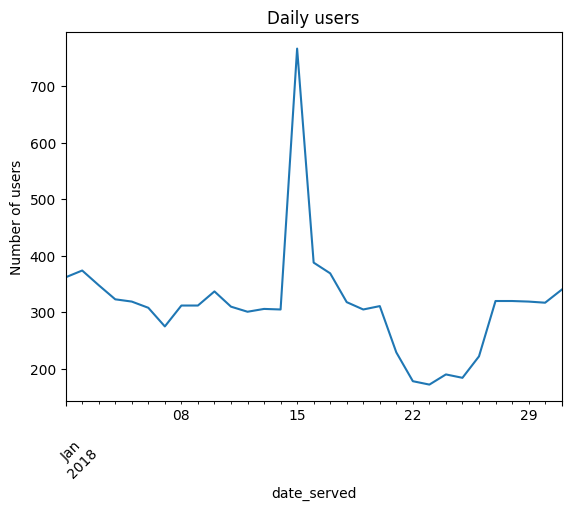

In [10]:
# Plot daily_users
daily_users.plot()

# Include a title and y-axis label
plt.title('Daily users')
plt.ylabel('Number of users')

# Rotate the x-axis labels by 45 degrees
plt.xticks(rotation = 45)

# Display the plot
plt.show()

## Conversion and retention rate

In [11]:
# Calculate the number of people we marketed to
total = marketing['user_id'].nunique()

# Calculate the number of people who subscribed
subscribers = marketing[marketing['converted']== True]['user_id'].nunique()

# Calculate the conversion rate
conversion_rate = subscribers/total
print(round(conversion_rate*100, 2), "%")

13.89 %


In [12]:
# Calculate the number of subscribers
total_subscribers = marketing[marketing['converted']== True]['user_id'].nunique()

# Calculate the number of people who remained subscribed
retained = marketing[marketing['is_retained']== True]['user_id'].nunique()

# Calculate the retention rate
retention_rate = retained/total_subscribers
print(round(retention_rate*100, 2), "%")

66.8 %


## Conversion rate - Segment

### Conversion rate - Lenguage

In [14]:
# Isolate english speakers
english_speakers = marketing[marketing['language_displayed'] == 'English']

# Calculate the total number of English speaking users
total = english_speakers['user_id'].nunique()

# Calculate the number of English speakers who converted
subscribers = english_speakers[english_speakers['converted'] == True]['user_id'].nunique()

# Calculate conversion rate
conversion_rate = subscribers/total
print('English speaker conversion rate:', round(conversion_rate*100,2), '%')

English speaker conversion rate: 12.92 %


In [15]:
# Group by language_displayed and count unique users
total = marketing.groupby(['language_displayed'])['user_id'].nunique()


# Group by language_displayed and count unique conversions
subscribers = marketing[marketing['converted'] == True].groupby(['language_displayed'])['user_id'].nunique()

# Calculate the conversion rate for all languages
language_conversion_rate = (subscribers/total)*100
print(language_conversion_rate)

language_displayed
Arabic     50.000000
English    12.916725
German     71.621622
Spanish    20.000000
Name: user_id, dtype: float64


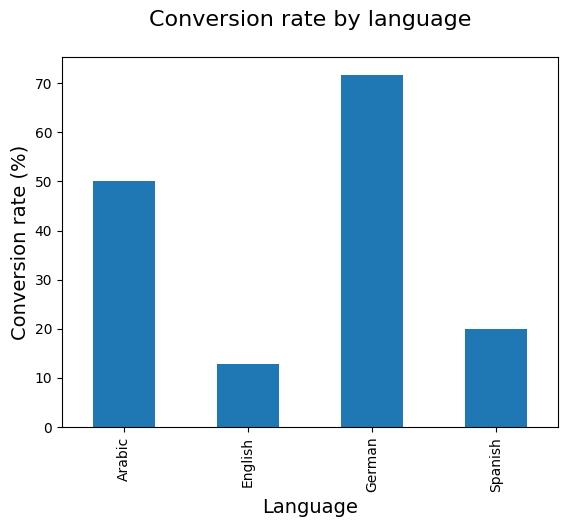

In [16]:
# Create a bar chart using language_conversion_rate DataFrame
language_conversion_rate.plot(kind = 'bar')

# Add a title and x and y-axis labels
plt.title('Conversion rate by language\n', size = 16)
plt.xlabel('Language', size = 14)
plt.ylabel('Conversion rate (%)', size = 14)

# Display the plot
plt.show()

### Daily Conversion Rate

In [17]:
# Group by date_served and count unique users cuando en el tiempo hubo mayor conversion 
total = marketing.groupby(['date_served'])['user_id'].nunique()

# Group by date_served and count unique converted users
subscribers = marketing[marketing['converted']== True].groupby(['date_served'])['user_id'].nunique()

# Calculate the conversion rate per day
daily_conversion_rate = subscribers/total
print(daily_conversion_rate)

date_served
2018-01-01    0.099448
2018-01-02    0.098930
2018-01-03    0.103448
2018-01-04    0.108359
2018-01-05    0.125392
2018-01-06    0.113636
2018-01-07    0.141818
2018-01-08    0.115385
2018-01-09    0.125000
2018-01-10    0.118694
2018-01-11    0.080645
2018-01-12    0.076412
2018-01-13    0.084967
2018-01-14    0.085246
2018-01-15    0.113429
2018-01-16    0.255155
2018-01-17    0.219512
2018-01-18    0.091195
2018-01-19    0.059016
2018-01-20    0.067524
2018-01-21    0.087336
2018-01-22    0.123596
2018-01-23    0.122093
2018-01-24    0.115789
2018-01-25    0.125000
2018-01-26    0.090090
2018-01-27    0.065625
2018-01-28    0.062500
2018-01-29    0.059561
2018-01-30    0.066246
2018-01-31    0.052941
Name: user_id, dtype: float64


In [18]:
# Reset index to turn the results into a DataFrame

daily_conversion_rate = pd.DataFrame(daily_conversion_rate.reset_index())

# Rename columns
daily_conversion_rate.columns = ['date_served', 'conversion_rate']

## Agrupation Analysis

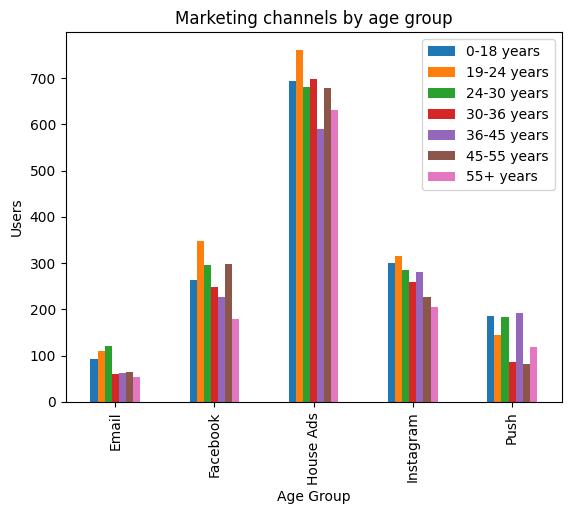

In [19]:
channel_age = marketing.groupby(['marketing_channel', 'age_group'])\
                                ['user_id'].count()

# Unstack channel_age and transform it into a DataFrame
channel_age_df = pd.DataFrame(channel_age.unstack(level = 1))

# Plot channel_age
channel_age_df.plot(kind = 'bar')
plt.title('Marketing channels by age group')
plt.xlabel('Age Group')
plt.ylabel('Users')
# Add a legend to the plot
plt.legend(loc = 'upper right', 
           labels = channel_age_df.columns.values)
plt.show()

## Retention Rate

In [21]:
# Count the subs by subscribing channel and day
retention_total = marketing.groupby(['date_subscribed',
                                     'subscribing_channel'])['user_id'].nunique()

# Print results
print(retention_total.head())



date_subscribed  subscribing_channel
2018-01-01       Email                   1
                 Facebook                8
                 House Ads              16
                 Instagram               8
                 Push                    3
Name: user_id, dtype: int64


In [22]:
# Sum the retained subs by subscribing channel and date subscribed
retention_subs = marketing[marketing['is_retained']== True].groupby(['date_subscribed','subscribing_channel'])['user_id'].nunique()

# Print results
print(retention_subs.head())

date_subscribed  subscribing_channel
2018-01-01       Email                   1
                 Facebook                7
                 House Ads              11
                 Instagram               6
                 Push                    3
Name: user_id, dtype: int64


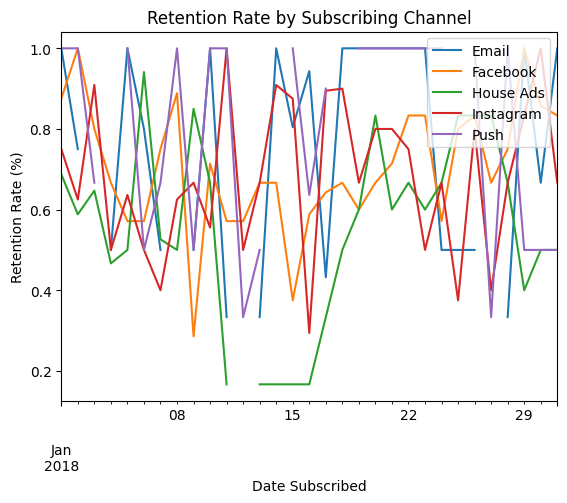

In [23]:
# Divide retained subscribers by total subscribers
retention_rate = retention_subs/retention_total
retention_rate_df = pd.DataFrame(retention_rate.unstack(level=1))

# Plot retention rate
retention_rate_df.plot()

# Add a title, x-label, y-label, legend and display the plot
plt.title('Retention Rate by Subscribing Channel')
plt.xlabel('Date Subscribed')
plt.ylabel('Retention Rate (%)')
plt.legend(loc='upper right', labels = retention_rate_df.columns.values)
plt.show()

## Functions

### Conversion Rate Function

In [26]:
def conversion_rate(dataframe, column_names):
    # Total number of converted users
    column_conv = dataframe[dataframe['converted']== True].groupby(column_names)['user_id'].nunique()

    # Total number users
    column_total = dataframe.groupby(column_names)['user_id'].nunique() 
    
    # Conversion rate 
    conversion_rate = column_conv/column_total
    
    # Fill missing values with 0
    conversion_rate = conversion_rate.fillna(0)
    return conversion_rate

date_served  age_group  
2018-01-01   0-18 years     0.155172
             19-24 years    0.196721
             24-30 years    0.105263
             30-36 years    0.040816
             36-45 years    0.042553
                              ...   
2018-01-31   24-30 years    0.057692
             30-36 years    0.000000
             36-45 years    0.035088
             45-55 years    0.023256
             55+ years      0.026316
Name: user_id, Length: 217, dtype: float64


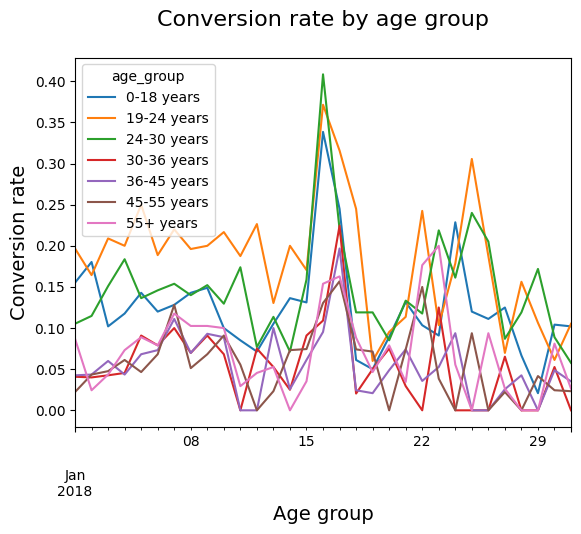

In [27]:
# Calculate conversion rate by age_group
age_group_conv = conversion_rate(marketing, ['date_served', 'age_group'])
print(age_group_conv)

# Unstack and create a DataFrame
age_group_df = pd.DataFrame(age_group_conv.unstack(level=1))

# Visualize conversion by age_group
age_group_df.plot()
plt.title('Conversion rate by age group\n', size = 16)
plt.ylabel('Conversion rate', size = 14)
plt.xlabel('Age group', size = 14)
plt.show()

In [28]:
def plotting_conv(dataframe):
    for column in dataframe:
        # Plot column by dataframe's index
        plt.plot(dataframe.index, dataframe[column])
        plt.title('Daily ' + str(column) + ' conversion rate\n', 
                  size = 16)
        plt.ylabel('Conversion rate', size = 14)
        plt.xlabel('Date', size = 14)
        # Show plot
        plt.show()  
        plt.clf()

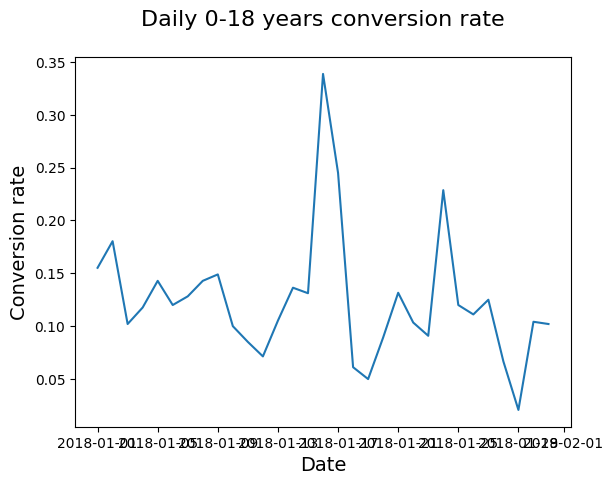

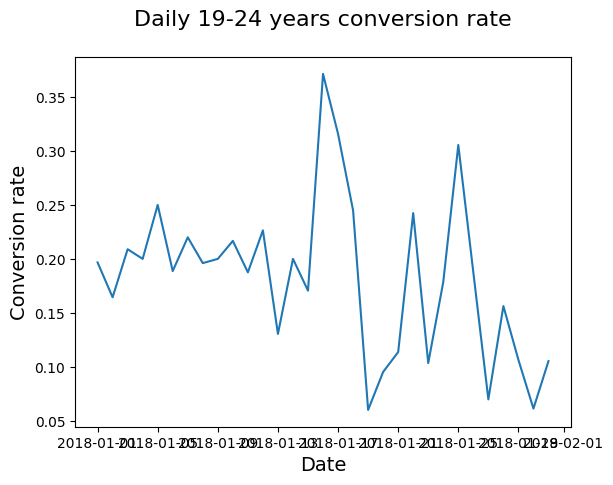

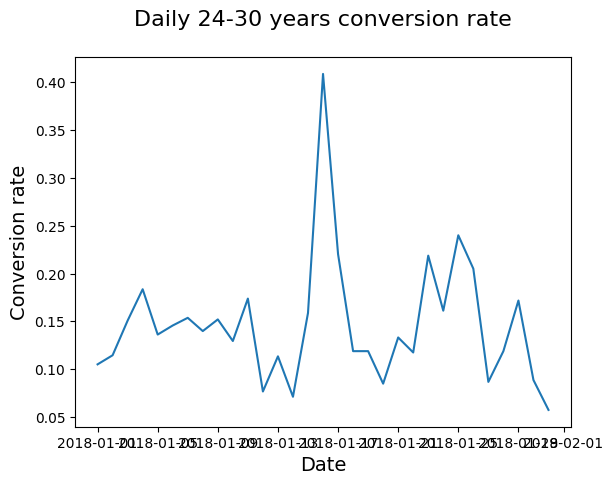

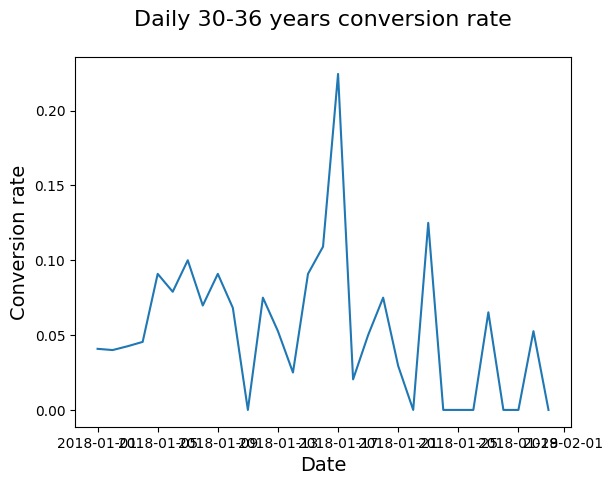

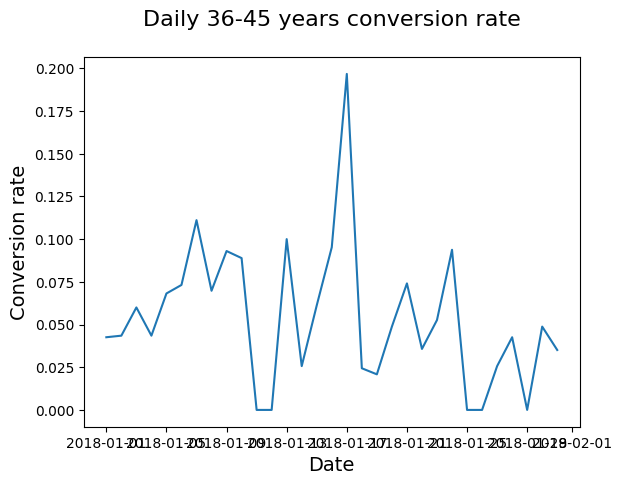

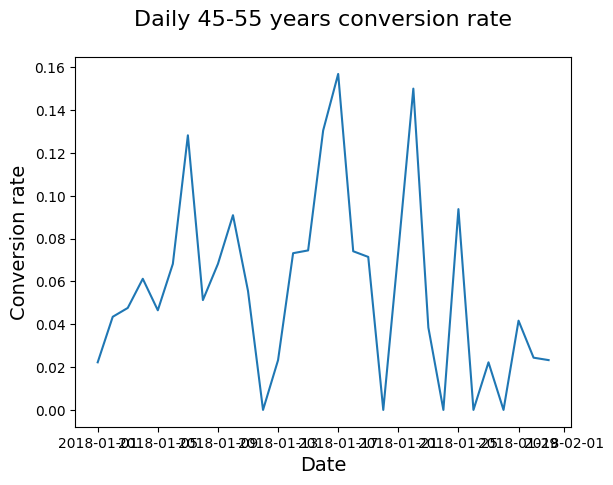

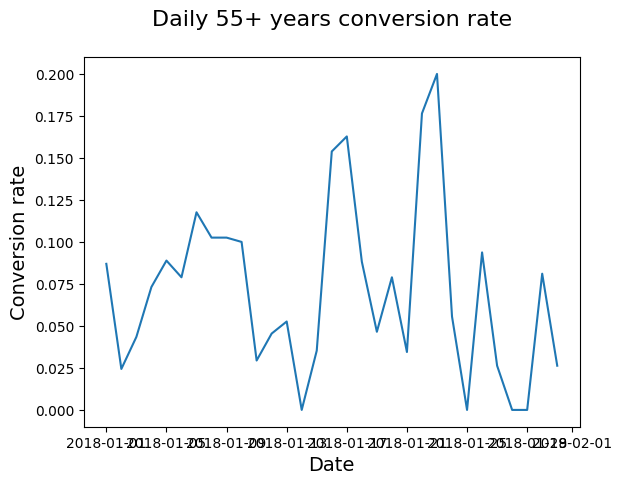

<Figure size 640x480 with 0 Axes>

In [29]:
# Calculate conversion rate by date served and age group
age_group_conv = conversion_rate(marketing, ['date_served', 'age_group'])

# Unstack age_group_conv and create a DataFrame
age_group_df = pd.DataFrame(age_group_conv.unstack(level=1))

# Plot the results
plotting_conv(age_group_df)

## Detect inconsistencies

## Calculate conversion rate by date served and channel

In [30]:
# Calculate conversion rate by date served and channel
daily_conv_channel = conversion_rate(marketing,['date_served', 'marketing_channel'])

print(daily_conv_channel.head())

date_served  marketing_channel
2018-01-01   Email                1.000000
             Facebook             0.117647
             House Ads            0.084656
             Instagram            0.106667
             Push                 0.083333
Name: user_id, dtype: float64


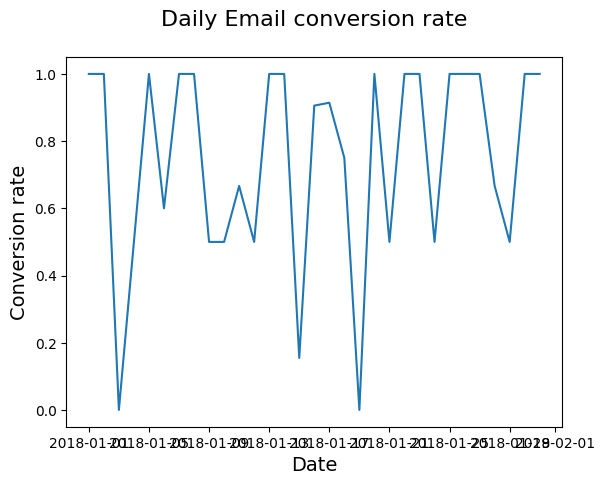

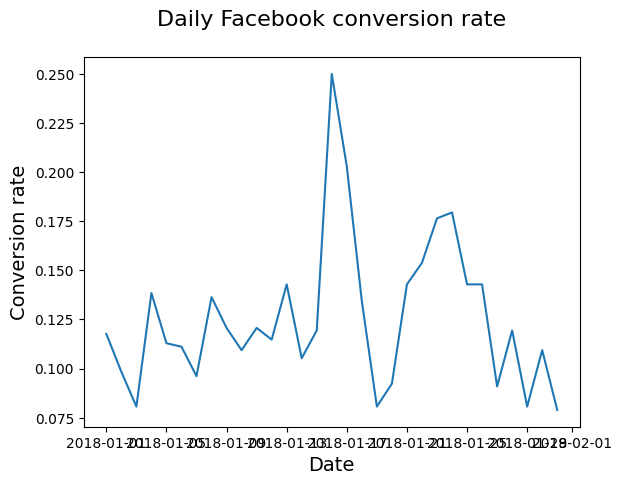

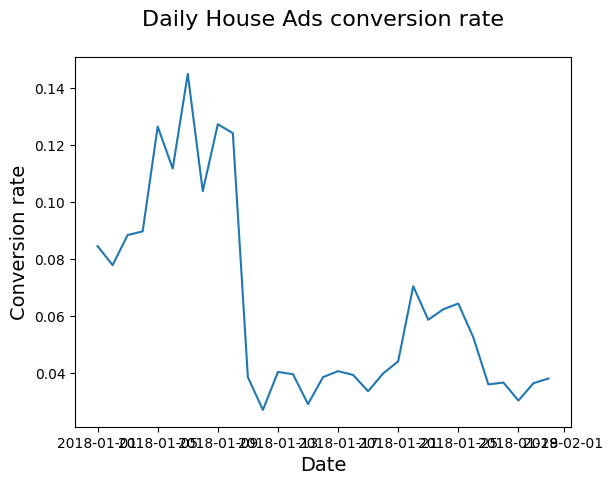

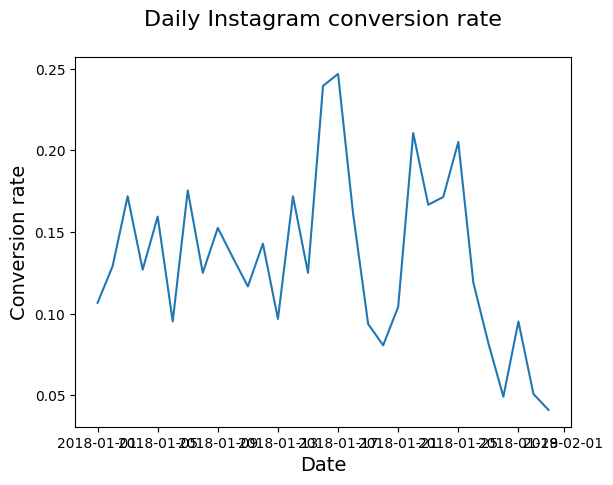

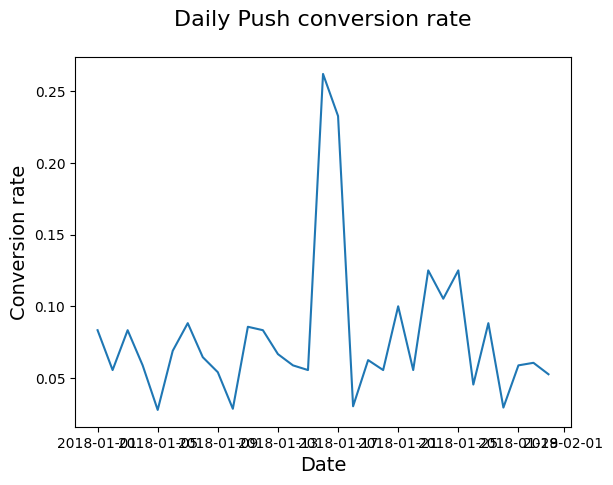

<Figure size 640x480 with 0 Axes>

In [31]:
# Calculate conversion rate by date served and channel
daily_conv_channel = conversion_rate(marketing, ['date_served', 
                                                 'marketing_channel'])

# Unstack daily_conv_channel and convert it to a DataFrame
daily_conv_channel = pd.DataFrame(daily_conv_channel.unstack(level = 1))

# Plot results of daily_conv_channel
plotting_conv(daily_conv_channel)

As we can see, email channel has te highest conversion rate at the larger of the time. During these period of time, has many days where the conversion rate reached almost 100%

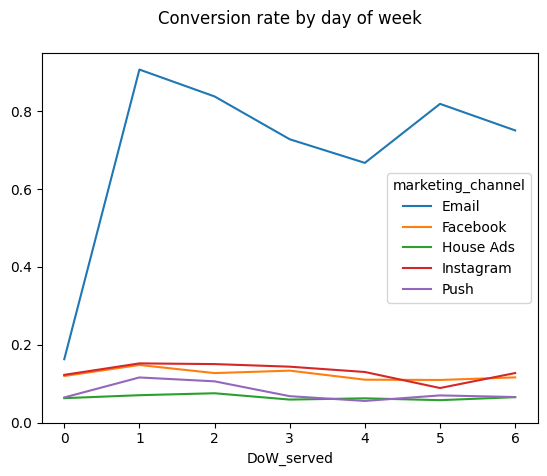

In [32]:
# Add day of week column to marketing
marketing['DoW_served'] = marketing['date_served'].dt.dayofweek

# Calculate conversion rate by day of week
DoW_conversion = conversion_rate(marketing, ['DoW_served', 'marketing_channel'])

# Unstack channels
DoW_df = pd.DataFrame(DoW_conversion.unstack(level=1))

# Plot conversion rate by day of week
DoW_df.plot()
plt.title('Conversion rate by day of week\n')
plt.ylim(0)

plt.show()

It's vital to identify if the fluctuations are due to expected shifts in user behavior (i.e., differences across the day of the week) versus a larger problem in technical implementation or marketing strategy. As we can see in the previous graphic, the conversion rate of email channel has the highest rate. In this case, the emails sended were more effectives. 

## Calculate conversion rate by date served and lenguage

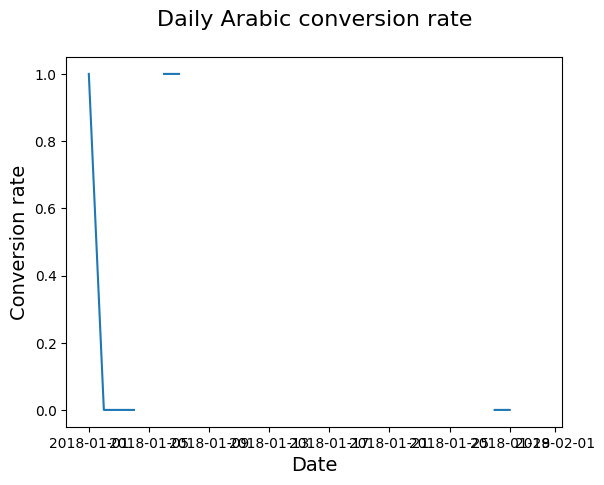

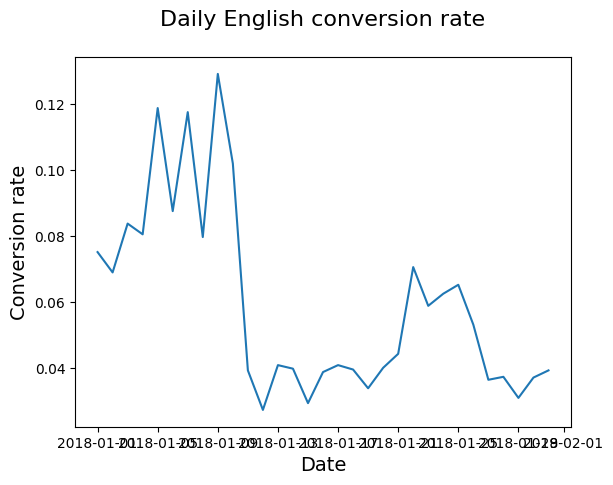

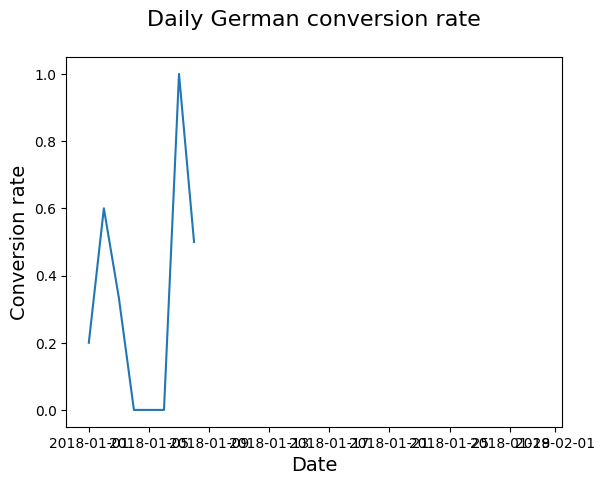

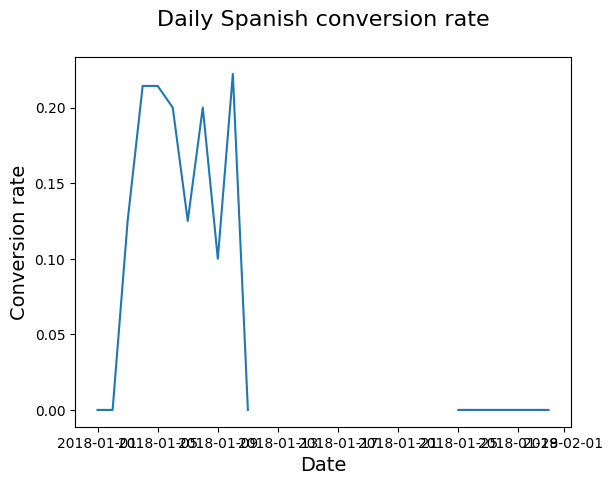

<Figure size 640x480 with 0 Axes>

In [33]:
# Isolate the rows where marketing channel is House Ads
house_ads = marketing[marketing['marketing_channel']== 'House Ads']

# Calculate conversion by date served, and language displayed
conv_lang_channel = conversion_rate(house_ads, ['date_served', 'language_displayed'])

# Unstack conv_lang_channel
conv_lang_df = pd.DataFrame(conv_lang_channel.unstack(level=1))

# Use your plotting function to display results
plotting_conv(conv_lang_df)

I analyzed conversion rates by language over time. This analysis aimed to determine whether the new marketing campaign was equally effective across different cultural and language segments.

By examining these patterns, I was able to identify whether the campaign messaging resonated differently with users from various linguistic backgrounds, highlighting potential cultural mismatches in the marketing strategy.

In [46]:
# Add the new column is_correct_lang
house_ads['is_correct_lang'] = np.where(
    house_ads['language_displayed'] == house_ads['language_preferred'], 
    'Yes', 
    'No')

# Groupby date_served and correct_language
language_check = house_ads.groupby(['date_served', 'is_correct_lang'])['is_correct_lang'].count()

# Unstack language_check and fill missing values with 0's
language_check_df = pd.DataFrame(language_check.unstack(level=1)).fillna(0)

# Print results
print(language_check_df)

is_correct_lang    No    Yes
date_served                 
2018-01-01        2.0  189.0
2018-01-02        3.0  247.0
2018-01-03        0.0  220.0
2018-01-04        0.0  168.0
2018-01-05        0.0  160.0
2018-01-06        1.0  151.0
2018-01-07        2.0  130.0
2018-01-08        0.0  154.0
2018-01-09        0.0  157.0
2018-01-10        0.0  170.0
2018-01-11       20.0  135.0
2018-01-12       18.0  130.0
2018-01-13       26.0  122.0
2018-01-14       20.0  131.0
2018-01-15       16.0  192.0
2018-01-16       28.0  127.0
2018-01-17       21.0  127.0
2018-01-18       31.0  121.0
2018-01-19       22.0  127.0
2018-01-20       28.0  124.0
2018-01-21       14.0  100.0
2018-01-22       13.0   72.0
2018-01-23       16.0   69.0
2018-01-24       13.0   83.0
2018-01-25       19.0   74.0
2018-01-26       24.0   92.0
2018-01-27       18.0  149.0
2018-01-28       28.0  136.0
2018-01-29       24.0  142.0
2018-01-30       23.0  145.0
2018-01-31       23.0  135.0


D:\Usuarios\RSanabria\AppData\Local\Temp\ipykernel_22248\3128284833.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  house_ads['is_correct_lang'] = np.where(


The number of errors in language assignment when displaying advertisements was analyzed. To do this, the language in which the ad was presented was compared with the user's preferred language. This analysis was conducted on a daily basis, counting the cases in which the displayed language matched the user’s preferred language and those in which a different language was shown.

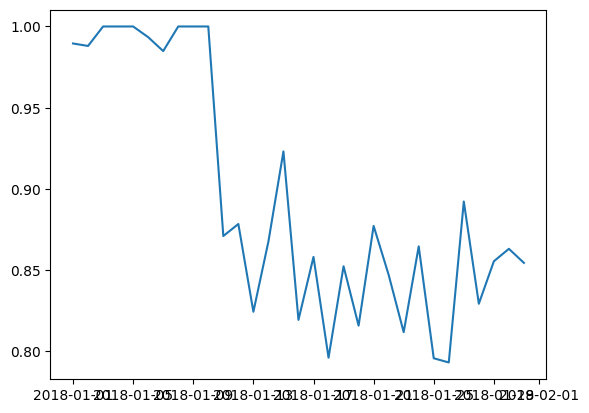

In [47]:
# Divide the count where language is correct by the row sum
language_check_df['pct'] = language_check_df['Yes']/language_check_df.sum(axis = 1)

# Plot and show your results
plt.plot(language_check_df.index.values, language_check_df['pct'])
plt.show()

After creating a DataFrame to verify whether users were shown advertisements in their preferred language, the next step was to quantify the issue. Specifically, the percentage of users who were served ads in an incorrect language was calculated. The results were then visualized to better understand the magnitude of the problem and how it evolved over time.

In [48]:
# Calculate pre-error conversion rate
house_ads_bug = house_ads[house_ads['date_served'] < '2018-01-11']
lang_conv = conversion_rate(house_ads_bug, 'language_displayed')

# Index other language conversion rate against English
spanish_index = lang_conv['Spanish']/lang_conv['English']
arabic_index = lang_conv['Arabic']/lang_conv['English']
german_index = lang_conv['German']/lang_conv['English']

print("Spanish index:", spanish_index)
print("Arabic index:", arabic_index)
print("German index:", german_index)

Spanish index: 1.681924882629108
Arabic index: 5.045774647887324
German index: 4.485133020344287


Now that it has been determined that language was indeed the cause of the house ads conversion issue, stakeholders need to understand how many potential subscribers were lost as a result of this error. To estimate this impact, the conversion rates of other languages were indexed against the English conversion rate during the period before the error appeared.

The analysis shows that Spanish has a higher conversion rate than English, while Arabic converts slightly better than English. These differences help estimate the number of potential subscribers that may have been lost due to the incorrect language assignment in the ads.

In [49]:
# Group house_ads by date and language
converted = house_ads.groupby(['date_served','language_preferred'])\
                        .agg({'user_id':'nunique',
                              'converted':'sum'})

# Unstack converted
converted_df = pd.DataFrame(converted.unstack(level = 1))

converted_df.head()

user_id                        converted                 \
language_preferred  Arabic English German Spanish    Arabic English German   
date_served                                                                  
2018-01-01             2.0   171.0    5.0    11.0         2      13      1   
2018-01-02             3.0   200.0    5.0    10.0         0      14      3   
2018-01-03             2.0   179.0    3.0     8.0         0      15      1   
2018-01-04             2.0   149.0    2.0    14.0         0      12      0   
2018-01-05             NaN   143.0    1.0    14.0       NaN      17  False   

                            
language_preferred Spanish  
date_served                 
2018-01-01               0  
2018-01-02               0  
2018-01-03               1  
2018-01-04               3  
2018-01-05               3

To understand the true impact of the error, it's crucial to determine how many subscribers we would have expected had the language error not occurred. This is essential for grasping the magnitude of the problem and the importance of preventing similar errors in the future.

In this step, you'll create a new DataFrame to perform calculations and determine the expected number of subscribers. This DataFrame will include the number of users who prefer each language per day. Once you have the DataFrame, you can begin calculating how many subscribers you would have expected had the language error not occurred.


In [50]:
# Create English conversion rate column for affected period
converted_df['english_conv_rate'] = converted_df.loc['2018-01-11':'2018-01-31'][('converted', 'English')]/converted_df.loc['2018-01-11':'2018-01-31'][('user_id', 'English')]

## agarro mi data frame y le digo que ubique las filas de ese rango de tiempod e enero y solo tome en cuenta la columna converted e english y user id e english
## luego lo divido para tener una tasa de referencia que es la tasa de conversion del idioma ingles.

# Create expected conversion rates for each language
converted_df['expected_spanish_rate'] = converted_df['english_conv_rate']*spanish_index ## aca lo que ehago es multiplicar mi indice, es decir el español convierte 2 veces mas que el ingles por decir por la tasa de conversion en condiciones normales del ingles. Es decir si la tasa de conversion es 0.5, en español en condiciones normales es el doble osea 1
converted_df['expected_arabic_rate'] = converted_df['english_conv_rate']*arabic_index
converted_df['expected_german_rate'] = converted_df['english_conv_rate']*german_index

## Entonces si español convierte 2 veces mas que ingles porque saque esa tasa dividiendo las tasas de conversion de español / ingles y resulta que español
## convierte dos meces mas, ebtonces por eso la multiplico por la tasa de ingles referencial, si esta fuera 0,5 x 2 entonces seria 1 ya que espalo convierte el doble

# Multiply number of users by the expected conversion rate
converted_df['expected_spanish_conv'] = converted_df[('user_id','Spanish')]*converted_df['expected_spanish_rate']/100
converted_df['expected_arabic_conv'] =converted_df[('user_id','Arabic')] * converted_df['expected_arabic_rate'] / 100
converted_df['expected_german_conv'] = converted_df[('user_id','German')] * converted_df['expected_german_rate'] / 100

## aca muktiolico los usuarios unicos por idioma que vieron mi publicidad, osea que no importa que vieron 5 veces, solo que la vieron una vez y lo multiplico 
## por mi tasa referencial que calcule antes para saber cuantos deberia haber tenido si todo salia bien, 

converted_df.head()

user_id                        converted                 \
language_preferred  Arabic English German Spanish    Arabic English German   
date_served                                                                  
2018-01-01             2.0   171.0    5.0    11.0         2      13      1   
2018-01-02             3.0   200.0    5.0    10.0         0      14      3   
2018-01-03             2.0   179.0    3.0     8.0         0      15      1   
2018-01-04             2.0   149.0    2.0    14.0         0      12      0   
2018-01-05             NaN   143.0    1.0    14.0       NaN      17  False   

                           english_conv_rate expected_spanish_rate  \
language_preferred Spanish                                           
date_served                                                          
2018-01-01               0               NaN                   NaN   
2018-01-02               0               NaN                   NaN   
2018-01-03               1               NaN                   NaN   
2018-01-04               3               NaN                   NaN   
2018-01-05               3               NaN                   NaN   

                   expected_arabic_rate expected_german_rate  \
language_preferred                                             
date_served                                                    
2018-01-01                          NaN                  NaN   
2018-01-02                          NaN                  NaN   
2018-01-03                          NaN                  NaN   
2018-01-04                          NaN                  NaN   
2018-01-05                          NaN                  NaN   

                   expected_spanish_conv expected_arabic_conv  \
language_preferred                                              
date_served                                                     
2018-01-01                           NaN                  NaN   
2018-01-02                           NaN                  NaN   
2018-01-03                           NaN                  NaN   
2018-01-04                           NaN                  NaN   
2018-01-05                           NaN                  NaN   

                   expected_german_conv  
language_preferred                       
date_served                              
2018-01-01                          NaN  
2018-01-02                          NaN  
2018-01-03                          NaN  
2018-01-04                          NaN  
2018-01-05                          NaN

Now that you've created an index to compare English conversion rates with those of all other languages, you'll create a DataFrame that estimates what the daily conversion rates should have been if users had received the correct language.

An expected conversion DataFrame called "converted" has been created that groups the house's ads by date and preferred language. It contains a unique user count, as well as the number of daily conversions for each language.

In [51]:
# Use .loc to slice only the relevant dates
converted = converted_df.loc['2018-01-11':'2018-01-31']

# Sum expected subscribers for each language
expected_subs = converted_df['expected_spanish_conv'].sum() + converted_df['expected_german_conv'].sum() + converted_df['expected_arabic_conv'].sum()

# Calculate how many subscribers we actually got
actual_subs = converted_df[('converted', 'Spanish')].sum() + converted_df[('converted', 'German')].sum() + converted_df[('converted', 'Arabic')].sum()

# Subtract how many subscribers we got despite the bug
lost_subs = actual_subs - expected_subs
print(lost_subs)

61.49542507526179


It's time to calculate how many subscribers were lost by mistakenly serving users in English instead of their preferred language.

## Hypotesys Tests - A/B Testing

The A/B testing refers to a randomized experiment that evaluates which variant performs better. For our tests to be meaningful, we must have a clear control. This control should be something existing and running in production. Each test variant should have only one significant change from the control; otherwise, it will be impossible to analyze what caused the change in key metrics. Before starting a test, you should develop a hypothesis and determine the metric you want to impact. Always establish key metrics before running the test. It's easy to redefine success in hindsight, especially if you're under pressure to get a positive result. By documenting success metrics in advance, you can maintain clarity about the test's success.

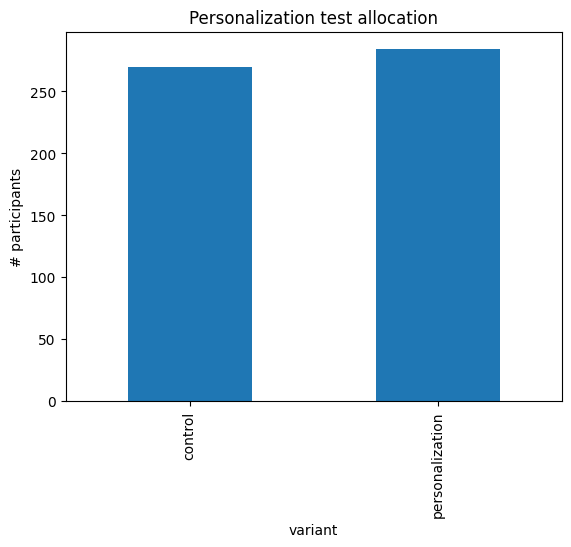

In [52]:
# Subset the DataFrame
email = marketing[marketing['marketing_channel'] == 'Email']

# Group the email DataFrame by variant 
alloc = email.groupby(['variant'])['user_id'].nunique()

# Plot a bar chart of the test allocation
alloc.plot(kind = 'bar')
plt.title('Personalization test allocation')
plt.ylabel('# participants')
plt.show()

Test Assignment.

The email portion of this campaign was run as an A/B test. Half of the emails sent consisted of generic, additional promotions for your product, while the other half contained personalized messages about user site usage. Before analyzing the results, we verified that users were assigned equally to the test and control groups.
The assignment is relatively equal, but not exactly the same. This is usually the case. If we are concerned that the assignment failed, there are statistical tests to determine the probability that the difference in assignment is due to chance. In this case, we will proceed assuming there were no problems with the randomization process.

In [53]:
# Group marketing by user_id and variant
subscribers = email.groupby(['user_id', 
                             'variant'])['converted'].max()
subscribers_df = pd.DataFrame(subscribers.unstack(level=1)) 

# Drop missing values from the control column
control = subscribers_df['control'].dropna()

# Drop missing values from the personalization column
personalization = subscribers_df['personalization'].dropna()

print('Control conversion rate:',np.mean(control) )
print('Personalization conversion rate:',  np.mean(personalization))

Control conversion rate: 0.2814814814814815
Personalization conversion rate: 0.3908450704225352


Now that we know the allocation is relatively even, let's analyze the conversion rate for the control and personalization groups. Since we chose conversion rate as the key metric for this test, it's crucial to assess whether the conversion rate was higher in the personalization treatment than in the control group.


In [54]:
def lift(a,b):
    # Calcuate the mean of a and b
    a_mean = np.mean(a)
    b_mean = np.mean(b)
    
    # Calculate the lift using a_mean and b_mean
    lift = (b_mean - a_mean)/a_mean
  
    return str(round(lift*100, 2)) + '%'
  
# Print lift() with control and personalization as inputs
print(lift(control, personalization))

38.85%


Creating a Lift Function

Lift can be calculated by dividing the difference between the treatment effect (or mean) and the control treatment effect by the control treatment effect. The formula for lift is shown before. The result is the percentage difference between the control and the treatment.

In [61]:
def ab_segmentation(segment):
  # Build a for loop for each subsegment in marketing
  for subsegment in np.unique(marketing[segment].values):
      print(subsegment)
      
      # Limit marketing to email and subsegment
      email = marketing[(marketing['marketing_channel'] == 'Email') & (marketing[segment] == subsegment)]

      subscribers = email.groupby(['user_id', 'variant'])['converted'].max()
      subscribers = pd.DataFrame(subscribers.unstack(level=1)) 
      control = pd.to_numeric(subscribers['control'], errors='coerce').dropna()
      personalization = pd.to_numeric(subscribers['personalization'], errors='coerce').dropna()

      print('lift:', lift(control, personalization)) 
      print('t-statistic:', stats.ttest_ind(control, personalization), '\n\n')

Creating an A/B Testing Segmentation Function

We observed that our personalization experiment was statistically highly significant. However, when running experiments, it's important to check how new features affect specific demographic groups. Sometimes, features that are very appealing to one group are less appealing to others.

Since we want to segment our data multiple times, we created an `ab_segmentation()` function that analyzes the impact of A/B testing on different data segments.

In [62]:
# Use ab_segmentation on language displayed
ab_segmentation('language_displayed')

Arabic
lift: 50.0%
t-statistic: TtestResult(statistic=np.float64(-0.5773502691896255), pvalue=np.float64(0.5795840000000001), df=np.float64(8.0)) 


English
lift: 39.0%
t-statistic: TtestResult(statistic=np.float64(-2.2183598646203215), pvalue=np.float64(0.026991701290720503), df=np.float64(486.0)) 


German
lift: -1.62%
t-statistic: TtestResult(statistic=np.float64(0.19100834180787182), pvalue=np.float64(0.8494394170062677), df=np.float64(42.0)) 


Spanish
lift: 166.67%
t-statistic: TtestResult(statistic=np.float64(-2.3570226039551585), pvalue=np.float64(0.040156718110477524), df=np.float64(10.0)) 




D:\Usuarios\RSanabria\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_axis_nan_policy.py:573: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


The impact of showing house ads in the user’s preferred language was analyzed across four language segments. The results are as follows:

- Arabic: Lift of 50%, but not statistically significant (p = 0.58). This suggests that while conversions were slightly higher in the personalized group, the difference could be due to random variation.

- English: Lift of 39%, statistically significant (p = 0.027). Showing ads in the correct language improved conversions in this segment.

- German: Lift of -1.62%, not significant (p = 0.85). No measurable impact of language personalization was observed.

- Spanish: Lift of 166.67%, statistically significant (p = 0.04). Personalizing the language had a strong positive effect on conversions for Spanish-speaking users.